<a href="https://colab.research.google.com/github/glisserok/grigoriyvolkov/blob/main/Laba4_KSVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Перші 5 рядків:
                     Month  America Tropical Interpretive Center  Avila Adobe  \
0  2014-01-01T00:00:00.000                                  6602        24778   
1  2014-02-01T00:00:00.000                                  5029        18976   
2  2014-03-01T00:00:00.000                                  8129        25231   
3  2014-04-01T00:00:00.000                                  2824        26989   
4  2014-05-01T00:00:00.000                                 10694        36883   

   Chinese American Museum  Gateway to Nature Center  Firehouse Museum  \
0                     1581                       NaN              4486   
1                     1785                       NaN              4172   
2                     3229                       NaN              7082   
3                     2129                       NaN              6756   
4                     3676                       NaN             10858   

   Hellman Quon  IAMLA  Pico House   Visitor Center/

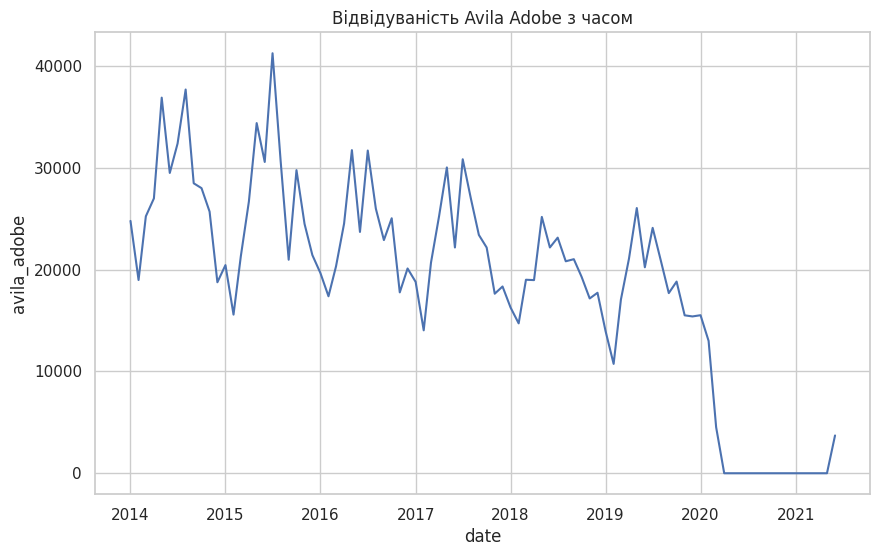

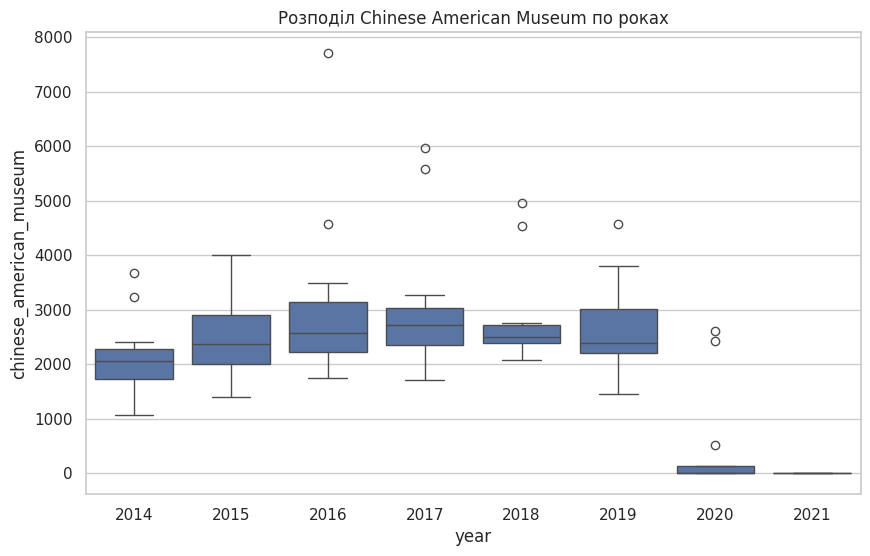

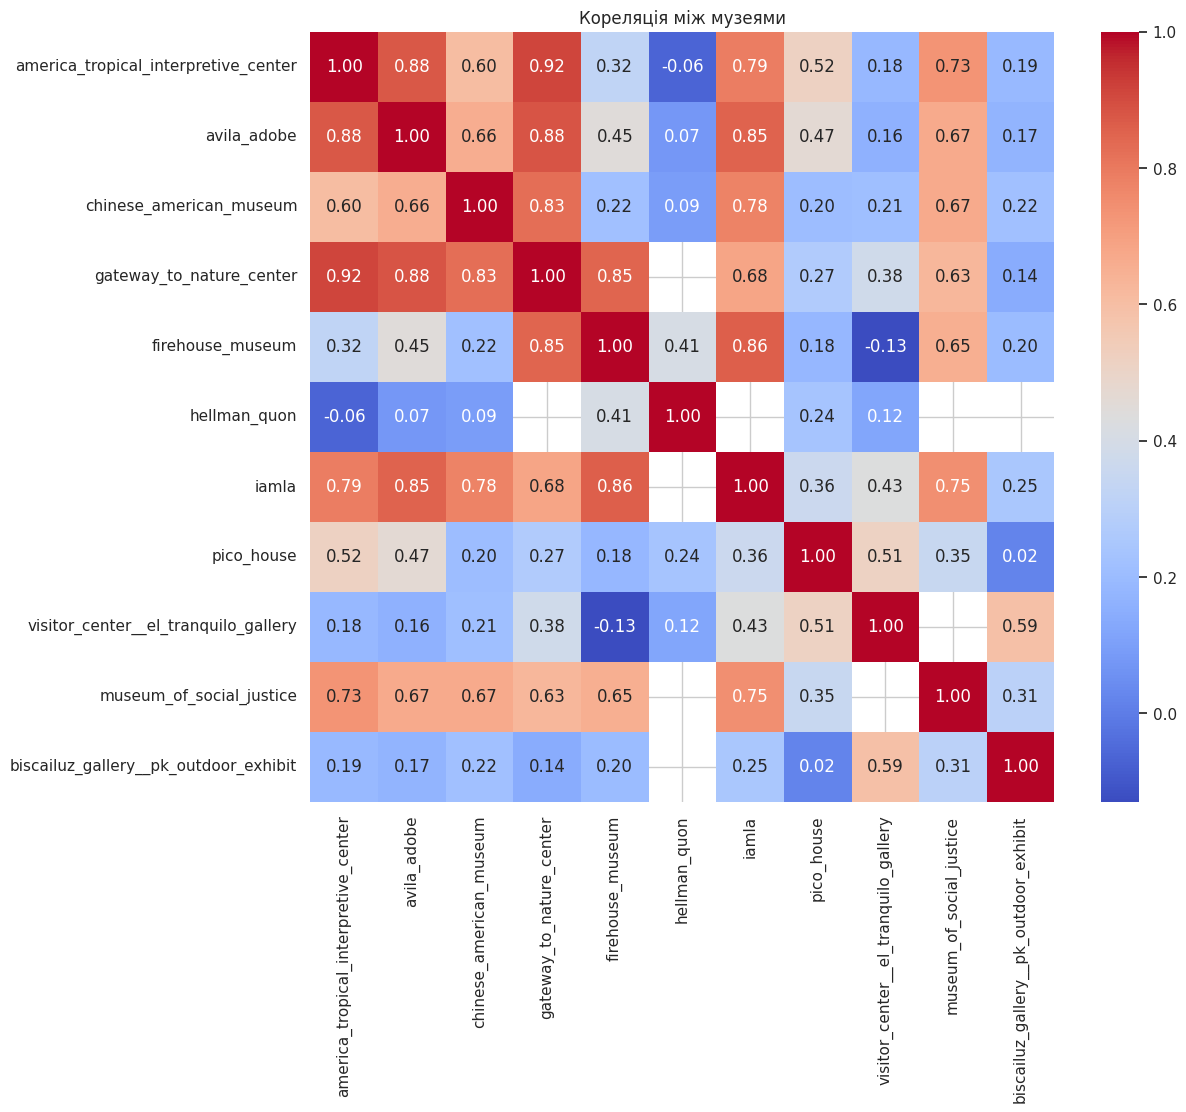

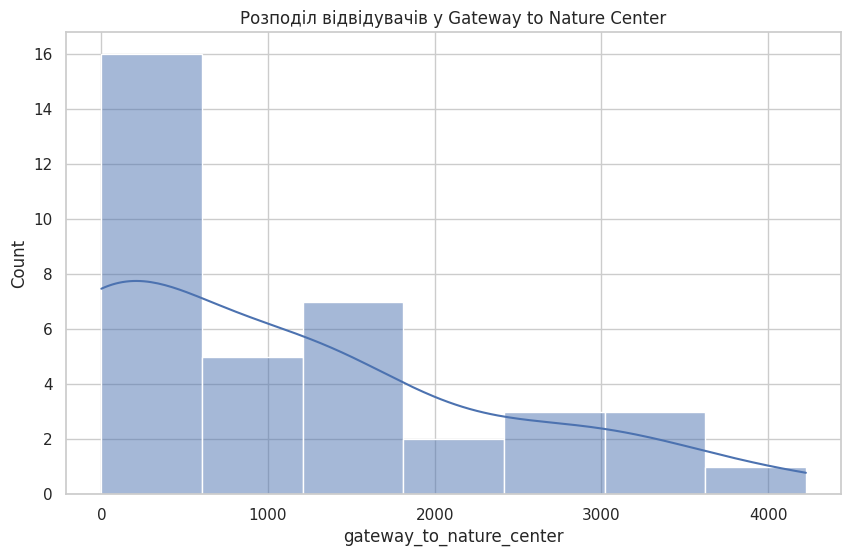

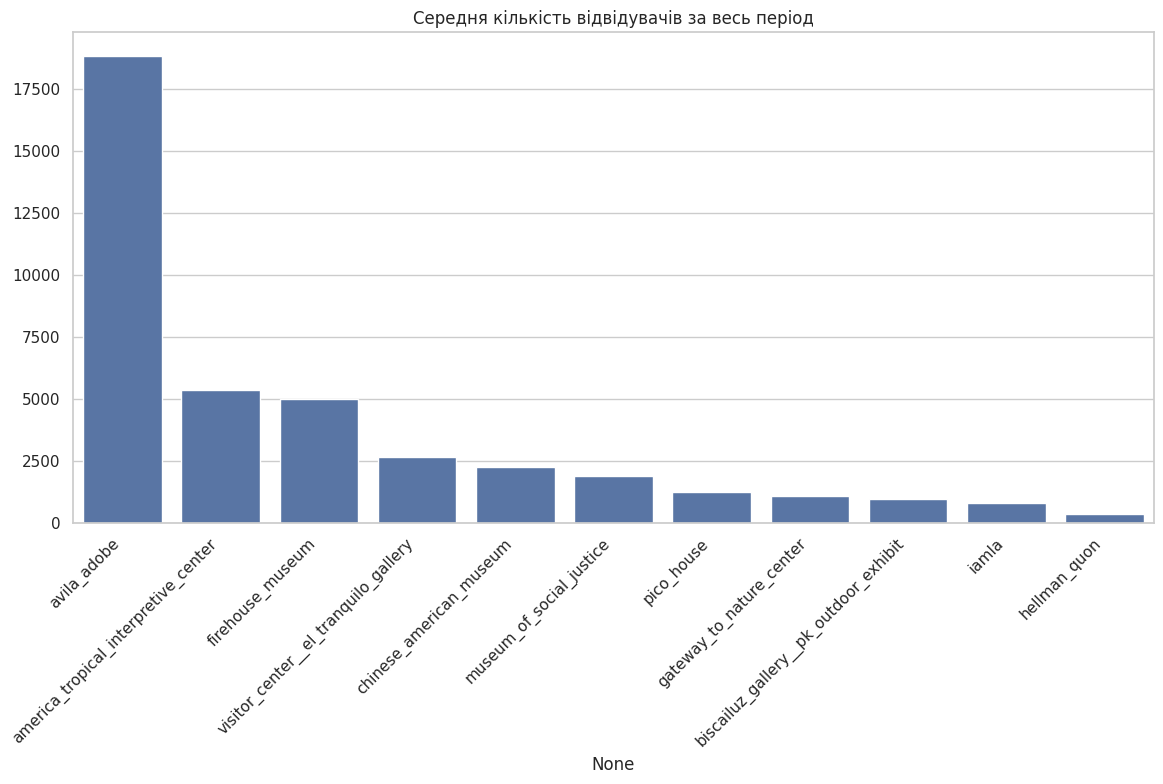

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('museum-visitors.csv')

print("Перші 5 рядків:")
print(df.head())

print(f"\nРозмір датасету: {df.shape}")
print("\nТипи даних:")
print(df.dtypes)
print("\nКількість пропусків у кожному стовпці:")
print(df.isna().sum())

duplicates = df.duplicated().sum()
print(f"\nКількість дублікатів: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Розмір таблиці після видалення дублікатів: {df.shape}")

df['Month'] = pd.to_datetime(df['Month'])
years = df['Month'].dt.year.unique()
print(f"\nДатасет містить інформацію за роки: {sorted(years)}")

df.columns = [col.lower().strip().replace(' ', '_').replace('/', '_') for col in df.columns]

df.rename(columns={'month': 'date'}, inplace=True)
print("\nОновлені назви стовпців:")
print(df.columns.tolist())

museum_cols = [col for col in df.columns if col != 'date']

avg_visitors = df[museum_cols].mean()
print("\nСередня кількість відвідувачів для кожного музею:")
print(avg_visitors)

df_2018 = df[df['date'].dt.year == 2018]
min_2018 = df_2018[museum_cols].min()
max_2018 = df_2018[museum_cols].max()
print("\nМінімальна кількість відвідувачів (2018):")
print(min_2018)
print("\nМаксимальна кількість відвідувачів (2018):")
print(max_2018)

df_2015 = df[df['date'].dt.year == 2015].copy()
df_2015['total_monthly'] = df_2015[museum_cols].sum(axis=1)
max_month_2015 = df_2015.loc[df_2015['total_monthly'].idxmax(), 'date'].month_name()
min_month_2015 = df_2015.loc[df_2015['total_monthly'].idxmin(), 'date'].month_name()
print(f"\n2015 рік: Місяць з найвищою відвідуваністю - {max_month_2015}")
print(f"2015 рік: Місяць з найнижчою відвідуваністю - {min_month_2015}")

summer_2018 = df_2018[df_2018['date'].dt.month.isin([6, 7, 8])]['avila_adobe'].sum()
winter_2018 = df_2018[df_2018['date'].dt.month.isin([12, 1, 2])]['avila_adobe'].sum()
print(f"\nAvila Adobe (2018): Кількість влітку - {summer_2018}, Кількість взимку - {winter_2018}")

df_2016 = df[df['date'].dt.year == 2016].copy()
df_2016['month_num'] = df_2016['date'].dt.month
correlation_2016 = df_2016[museum_cols + ['month_num']].corr()['month_num'].drop('month_num')
print("\nКореляція між відвідуваністю та номером місяця (2016):")
print(correlation_2016)

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='date', y='avila_adobe')
plt.title('Відвідуваність Avila Adobe з часом')
plt.savefig('avila_adobe_line.png')

plt.figure(figsize=(10, 6))
df['year'] = df['date'].dt.year
sns.boxplot(x='year', y='chinese_american_museum', data=df)
plt.title('Розподіл Chinese American Museum по роках')
plt.savefig('chinese_american_boxplot.png')

plt.figure(figsize=(12, 10))
sns.heatmap(df[museum_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Кореляція між музеями')
plt.savefig('museum_heatmap.png')

plt.figure(figsize=(10, 6))
sns.histplot(df['gateway_to_nature_center'].dropna(), kde=True)
plt.title('Розподіл відвідувачів у Gateway to Nature Center')
plt.savefig('gateway_histogram.png')

plt.figure(figsize=(12, 8))
avg_visitors_sorted = avg_visitors.sort_values(ascending=False)
sns.barplot(x=avg_visitors_sorted.index, y=avg_visitors_sorted.values)
plt.xticks(rotation=45, ha='right')
plt.title('Середня кількість відвідувачів за весь період')
plt.tight_layout()
plt.savefig('average_visitors_bar.png')

Museum.csv:
https://www.kaggle.com/datasets/cityofLA/los-angeles-museum-visitors

GitHub:
https://github.com/glisserok/grigoriyvolkov/blob/main/Laba4_KSVD.ipynb